# NumPy Workshop: Build Your Own Grade Calculator

**Time:** ~90 minutes

### The Big Picture
Today you'll use NumPy (vectors and matrices) to build a tool that could actually calculate grades for a whole class. We'll do it in 5 steps:

1. Vector warm-up: describe one student's performance with stats, norm, and distance
2. **The mystery weights:** the grading formula got lost — recover it by solving a system of equations with a matrix inverse
3. Dot product: apply the recovered weights to a single student, the fast way
4. Scale up to a whole class of students (matrices)
5. **Capstone:** grade the entire class at once and build a full report card with a chart

Each question builds on the one before it, so try not to skip ahead. Raise your hand any time you get stuck!

Run the cell below first — it sets up everything you need.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)
print("Ready to go!")

Ready to go!


---
## Question 1: Sizing Up a Student (Vectors)

Here are two students' raw scores on 4 assignments (Homework, Quiz, Midterm, Final):

| Student | Homework | Quiz | Midterm | Final |
|---|---|---|---|---|
| Alex | 85 | 90 | 78 | 92 |
| Bao | 70 | 65 | 80 | 75 |

We don't know the grading weights yet (that's next question's mystery!). For now, let's just get comfortable describing these score vectors with NumPy.

**Your tasks:**
1. Store each student's scores as a NumPy array: `alex` and `bao`.
2. Find Alex's `mean`, `max`, and `min` score.
3. Compute the **norm** (magnitude) of Alex's score vector using `np.linalg.norm(alex)`. This squares every entry, adds them up, and takes the square root — it's a single number that summarizes the overall "size" of the vector.
4. Compute the **Euclidean distance** between Alex and Bao's score vectors: `np.linalg.norm(alex - bao)`. This tells you how *different* their performance profiles are — a smaller number means more similar performance across all 4 assignments.

In [2]:
# TODO: create the arrays
alex = np.array([85, 90, 78, 92])
bao = np.array([70, 65, 80, 75])

# TODO: Alex's basic stats
mean_score = alex.mean()
max_score = alex.max()
min_score = alex.min()

# TODO: norm (magnitude) of Alex's score vector
alex_norm = np.linalg.norm(alex)

# TODO: Euclidean distance between Alex and Bao
distance = np.linalg.norm(alex-bao)

print("Mean:", mean_score)
print("Max:", max_score)
print("Min:", min_score)
print("Alex's norm:", alex_norm)
print("Distance between Alex and Bao:", distance)

Mean: 86.25
Max: 92
Min: 78
Alex's norm: 172.8380745090618
Distance between Alex and Bao: 33.80828300875393


**Check your work:** Mean `86.25`, Max `92`, Min `78`. Alex's norm should be about `172.84`. The distance between Alex and Bao should be about `33.81`.

---
## Question 2: The Mystery Weights (Matrix Inverse)

Every assignment (Homework, Quiz, Midterm, Final) counts a different amount toward the final grade — but the sheet listing the exact weights got lost! Here's what we still have from last year's records: 4 "reference" students, their raw scores on the same 4 assignments, **and** their already-published official final grades.

Run the cell below to load this reference data — don't change it.

In [3]:
# reference_scores: rows = 4 reference students, columns = [Homework, Quiz, Midterm, Final]
reference_scores = np.array([
    [100, 100, 100, 100],
    [80, 100, 100, 100],
    [80, 80, 100, 100],
    [80, 80, 80, 100],
], dtype=float)

# their already-published official final grades, in the same student order
reference_grades = np.array([100, 96, 92, 86], dtype=float)

print("reference_scores:\n", reference_scores)
print("reference_grades:", reference_grades)

reference_scores:
 [[100. 100. 100. 100.]
 [ 80. 100. 100. 100.]
 [ 80.  80. 100. 100.]
 [ 80.  80.  80. 100.]]
reference_grades: [100.  96.  92.  86.]


Since every student is graded with the same 4 weights, `reference_scores @ weights = reference_grades`. That's just like a system of 4 linear equations with 4 unknowns (the kind you've solved in algebra) — except now it's one matrix equation.

If `A @ w = b`, then `w = A⁻¹ @ b`, where `A⁻¹` is the **matrix inverse**. In NumPy: `np.linalg.inv(A) @ b`.

One catch: a matrix only has an inverse if its **determinant** is not zero (`np.linalg.det(A) != 0`). If the determinant were 0, the system wouldn't have a single unique solution — so it's good practice to check this first.

**Your tasks:**
1. Compute the determinant of `reference_scores` with `np.linalg.det`. Confirm it's not zero.
2. Compute the inverse of `reference_scores` with `np.linalg.inv`.
3. Recover the mystery weights: `weights = np.linalg.inv(reference_scores) @ reference_grades`.
4. Sanity check: the 4 weights should add up to (approximately) `1.0`, since together they make up 100% of the grade.

In [5]:
# TODO: determinant of reference_scores
det = np.linalg.det(reference_scores)


# TODO: inverse of reference_scores
if (det!=0):

    reference_scores_inv = np.linalg.inv(reference_scores)


# TODO: recover the weights
    weights = np.linalg.inv(reference_scores) @ reference_grades

# TODO: do the weights add up to ~1.0?
weights_sum = weights.sum()

print("Determinant:", det)
print("Recovered weights:", weights)
print("Weights sum to:", weights_sum)

Determinant: 799999.999999999
Recovered weights: [0.2 0.2 0.3 0.3]
Weights sum to: 1.0


**Check your work:** Determinant should be `800000.0` (definitely not zero). Recovered weights should be about `[0.2, 0.2, 0.3, 0.3]` — Homework 20%, Quiz 20%, Midterm 30%, Final 30%. They should sum to `1.0`.

Keep `weights` around — you'll use it for the rest of the notebook.

---
## Question 3: Grade Alex (Dot Product)

Now that the mystery weights are recovered, let's put them to use. Multiplying two vectors element-wise and then summing them up is such a common operation that NumPy has a single function for it: the **dot product**, `np.dot(a, b)` (you can also write it as `a @ b`).

**Your tasks:**
1. Calculate Alex's weighted final grade using `np.dot(alex, weights)` (or `alex @ weights`). Store it in `alex_grade`.
2. Double check it by computing the same thing manually (element-wise multiply, then `.sum()`), and confirm the two match with `np.isclose()`.

Why does this matter? Because once we have many students, doing things "manually" gets messy fast. The dot product is the building block for everything that comes next.

In [6]:
# TODO: Alex's weighted grade using the dot product
alex_grade = np.dot(alex, weights)

# TODO: same thing calculated manually (element-wise multiply, then sum)
alex_grade_manual = np.multiply(alex, weights).sum()

# TODO: do they match?
matches = alex_grade == alex_grade_manual

print("Alex's grade (dot product):", alex_grade)
print("Alex's grade (manual):", alex_grade_manual)
print("Matches?", matches)

Alex's grade (dot product): 86.0
Alex's grade (manual): 86.0
Matches? True


**Check your work:** Alex's grade should be about `86.0`, and both methods should match.

---
## Question 4: A Whole Class (Matrices)

Real classes have more than one student. Below is a matrix where **each row is a student** and **each column is an assignment** (same 4 assignments as before: Homework, Quiz, Midterm, Final). Notice Alex and Bao's rows match the vectors from Question 1!

Run the cell below to load the class data — don't change it.

In [8]:
student_names = np.array(["Alex", "Bao", "Camila", "Dev", "Ekene", "Farah"])

# rows = students, columns = [Homework, Quiz, Midterm, Final]
class_scores = np.array([
    [85, 90, 78, 92],
    [70, 65, 80, 75],
    [95, 98, 91, 97],
    [60, 72, 55, 68],
    [88, 84, 90, 93],
    [77, 80, 73, 82],
])

print("Shape of class_scores:", class_scores.shape)

Shape of class_scores: (6, 4)


**Your tasks:**
1. Print the shape of `class_scores` and, in a comment, note what each number means (how many students? how many assignments?).
2. Use indexing to get **Camila's** full row of scores. (Hint: check her position in `student_names` — remember indexing starts at 0!)
3. Use indexing/slicing to get **everyone's Quiz score** (the whole column). Store it as `quiz_scores`.
4. Calculate the **average score per assignment** across all students (this is `axis=0`). Store it as `avg_per_assignment`.
5. Calculate the **average score per student** across all their assignments (this is `axis=1`). Store it as `avg_per_student`.

In [14]:
print(class_scores.shape)
## there are 4 assignments for each of the 6 students
# TODO: Camila's row
camila_scores = class_scores[student_names =="Camila"]

# TODO: everyone's quiz scores (column 1)
quiz_scores = class_scores[:, 1]

# TODO: average per assignment (axis=0)
avg_per_assignment = np.mean(class_scores, axis = 0)

# TODO: average per student (axis=1)
avg_per_student = np.mean(class_scores, axis = 1)

print("Camila's scores:", camila_scores)
print("Quiz scores:", quiz_scores)
print("Average per assignment:", avg_per_assignment)
print("Average per student:", avg_per_student)

(6, 4)
Camila's scores: [[95 98 91 97]]
Quiz scores: [90 65 98 72 84 80]
Average per assignment: [79.17 81.5  77.83 84.5 ]
Average per student: [86.25 72.5  95.25 63.75 88.75 78.  ]


**Check your work:** Camila's scores should be `[95, 98, 91, 97]`. The Midterm average (3rd value in `avg_per_assignment`) should be `77.83`.

---
## Question 5 (Capstone): Build the Full Report Card

Time to combine everything into one finished product: grade the entire class at once, apply a curve, assign letter grades, and chart the results.

In Question 3, you learned that `alex @ weights` gives you one student's weighted grade. It turns out the **exact same operation** works on the whole class matrix at once: `class_scores @ weights` multiplies every row by `weights` and sums each one — giving you every student's weighted grade in a single line.

**Your tasks:**

1. Calculate `final_grades = class_scores @ weights` (reuse the `weights` you recovered in Question 2).
2. Your school just announced a **6-point curve** for everyone. Add 6 to every student's grade using broadcasting, then use `np.clip(array, min, max)` to cap grades at 100 (a grade can't go above 100!). Store the result as `curved_grades`.
3. Assign each student a letter grade using this scale:
   - 90 and above → `"A"`
   - 80 to 89.99 → `"B"`
   - 70 to 79.99 → `"C"`
   - below 70 → `"F"`

   Hint: `np.select()` can do this in one shot. It takes a list of conditions and a matching list of results:
   ```python
   conditions = [curved_grades >= 90, curved_grades >= 80, curved_grades >= 70]
   results = ["A", "B", "C"]
   letter_grades = np.select(conditions, results, default="F")
   ```

4. Build a `pandas` DataFrame called `report_card` with columns `"Name"`, `"Final Grade"`, and `"Letter Grade"`, using `student_names`, `curved_grades`, and `letter_grades`. Sort it from highest to lowest grade (`.sort_values()`).

5. Find the class average grade, and the name of the top-scoring student. (Hint: `np.argmax()` gives you the *index* of the highest value — use it with `student_names`.)

6. Make a bar chart with `matplotlib`: one bar per student showing their final grade, with a horizontal line showing the class average. Label your axes and give the chart a title!

In [22]:
# TODO: 1. weighted grade for every student, in one line
final_grades = class_scores @ weights

# TODO: 2. add a 6-point curve, then cap at 100 with np.clip
curved_grades = np.clip(final_grades+6, 0, 100)

# TODO: 3. assign letter grades
conditions = ([curved_grades>=90, curved_grades>=80, curved_grades>=0])
results = ["A", "B", "C"]
letter_grades = np.select(conditions, results, default = "F")

# TODO: 4. build the report_card DataFrame
report_card = pd.DataFrame({"Name":student_names, "Final Grade":curved_grades, "Letter Grade":letter_grades})


# TODO: sort by Final Grade, highest first
report_card_sorted = report_card.sort_values(by="Final Grade", ascending = False)

# TODO: 5. class average and top student
class_average = curved_grades.mean()
top_student = student_names[np.argmax(curved_grades)]

print(report_card_sorted)
print("\nClass average:", class_average)
print("Top student:", top_student)

     Name  Final Grade Letter Grade
2  Camila        100.0            A
4   Ekene         95.3            A
0    Alex         92.0            A
5   Farah         83.9            B
1     Bao         79.5            C
3     Dev         69.3            C

Class average: 86.66666666666667
Top student: Camila


**Check your work:** `final_grades[0]` (Alex, uncurved) should be `86.0` — matching Question 3! The report card's **Final Grade** column is the *curved* value (`final_grades + 6`, capped at 100), so Alex's row should read `92.0`, and Camila's (index 2) should be capped at exactly `100.0` since `95.0 + 6` would otherwise be `101`. Class average should be about `86.67`, and the top student should be `Camila`.

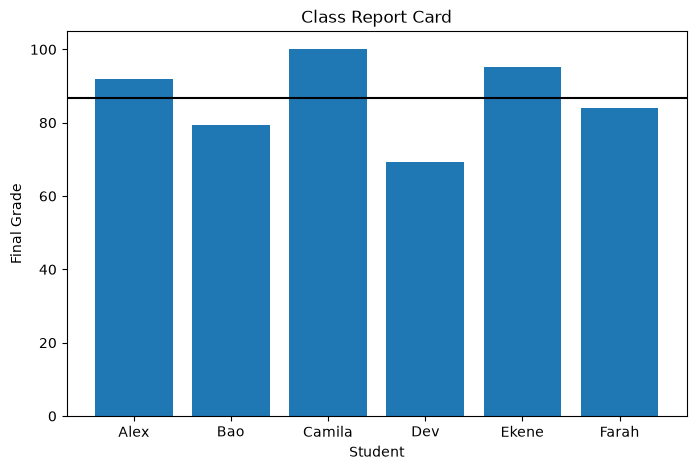

In [24]:
# TODO: 6. bar chart of final grades with a class-average line
plt.figure(figsize=(8, 5))

# your bar chart code here
plt.bar(student_names, curved_grades)

# your horizontal average line here (hint: plt.axhline)
plt.axhline(y=class_average, color = "black")

plt.xlabel("Student")
plt.ylabel("Final Grade")
plt.title("Class Report Card")
plt.show()

### Bonus (if you finish early)
- Instead of 4 reference students, what if we only had 3? Try removing a row from `reference_scores` and `reference_grades` in Question 2 and see what error NumPy gives you when you try to invert a non-square matrix.
- Color each bar in the chart by letter grade (e.g. green for A, blue for B, orange for C, red for F).
- Add a 7th student of your own choosing and see how they'd rank.